In [35]:
# PRODIGY INFOTECH - DATA SCIENCE
# TASK 03: Decision Tree Classifier

## Objective
print('Objective')
print('''To build a Decision Tree Classifier to predict whether a customer
will subscribe to a term deposit based on the customer's demographic
and marketing campaign information.''')

## Dataset Description
print('Dataset Description')
print('''The Bank Marketing dataset contains information about direct
marketing campaigns conducted by a Portuguese banking institution.
The objective is to predict whether a client will subscribe to a
term deposit.''')

Objective
To build a Decision Tree Classifier to predict whether a customer
will subscribe to a term deposit based on the customer's demographic
and marketing campaign information.
Dataset Description
The Bank Marketing dataset contains information about direct
marketing campaigns conducted by a Portuguese banking institution.
The objective is to predict whether a client will subscribe to a
term deposit.


In [36]:
# --------------------------------------------
# 1. Import required libraries
# --------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
# --------------------------------------------
# 2. Upload and load the dataset
# --------------------------------------------

from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)

Saving bank+marketing.zip to bank+marketing (1).zip
Uploaded file: bank+marketing (1).zip


In [38]:
# --------------------------------------------
# 3. Extract the ZIP file
# --------------------------------------------

import zipfile
import os

extract_folder = "bank_marketing_data"

with zipfile.ZipFile(filename, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP file extracted successfully!")

print("\nFiles inside the extracted folder:")
for root, directories, filenames in os.walk(extract_folder):
    for file in filenames:
        print(os.path.join(root, file))

ZIP file extracted successfully!

Files inside the extracted folder:
bank_marketing_data/bank.zip
bank_marketing_data/bank-additional.zip


In [39]:
# --------------------------------------------
# 4. Extract bank.zip
# --------------------------------------------

bank_zip = os.path.join(extract_folder, "bank_marketing_data", "bank.zip")

In [40]:
# --------------------------------------------
# 4. Extract bank.zip
# --------------------------------------------

bank_zip = os.path.join(extract_folder, "bank.zip")

bank_extract_folder = "bank_data"

with zipfile.ZipFile(bank_zip, "r") as zip_ref:
    zip_ref.extractall(bank_extract_folder)

print("bank.zip extracted successfully!")

print("\nFiles inside bank.zip:")
for root, directories, filenames in os.walk(bank_extract_folder):
    for file in filenames:
        print(os.path.join(root, file))

bank.zip extracted successfully!

Files inside bank.zip:
bank_data/bank.csv
bank_data/bank-full.csv
bank_data/bank-names.txt


In [41]:
# --------------------------------------------
# 5. Load the Bank Marketing dataset
# --------------------------------------------

csv_file = os.path.join(bank_extract_folder, "bank-full.csv")

df = pd.read_csv(csv_file, sep=";")

print("\nDataset loaded successfully!")


Dataset loaded successfully!


In [42]:
# --------------------------------------------
# 6. Display first 5 rows
# --------------------------------------------

print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [43]:
# --------------------------------------------
# 7. Display dataset information
# --------------------------------------------

print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [44]:
# --------------------------------------------
# 8. Display dataset shape
# --------------------------------------------

print("\nDataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset Shape:
Rows: 45211
Columns: 17


In [45]:
# --------------------------------------------
# 9. Check missing values
# --------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [46]:
# --------------------------------------------
# 10. Check duplicate rows
# --------------------------------------------

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
0


In [47]:
# --------------------------------------------
# 11. Check data types
# --------------------------------------------

print("\nData Types:")
print(df.dtypes)


Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [48]:
# --------------------------------------------
# 12. Separate Features and Target
# --------------------------------------------

X = df.drop(columns=["y"])
y = df["y"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)


Features:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

Target:
y


In [49]:
# --------------------------------------------
# 13. Encode Categorical Variables
# --------------------------------------------

X_encoded = pd.get_dummies(X, drop_first=True)

print("\nEncoded Features:")
print(X_encoded.head())

print("\nShape after encoding:")
print(X_encoded.shape)


Encoded Features:
   age  balance  day  duration  campaign  pdays  previous  job_blue-collar  \
0   58     2143    5       261         1     -1         0            False   
1   44       29    5       151         1     -1         0            False   
2   33        2    5        76         1     -1         0            False   
3   47     1506    5        92         1     -1         0             True   
4   33        1    5       198         1     -1         0            False   

   job_entrepreneur  job_housemaid  ...  month_jul  month_jun  month_mar  \
0             False          False  ...      False      False      False   
1             False          False  ...      False      False      False   
2              True          False  ...      False      False      False   
3             False          False  ...      False      False      False   
4             False          False  ...      False      False      False   

   month_may  month_nov  month_oct  month_sep  poutcome

In [50]:
# --------------------------------------------
# 14. Split the dataset into training and testing sets
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (36168, 42)
Testing set size: (9043, 42)


In [51]:
# --------------------------------------------
# 15. Create Decision Tree Classifier
# --------------------------------------------

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

print("Decision Tree Classifier created successfully!")

Decision Tree Classifier created successfully!


In [52]:
# --------------------------------------------
# 16. Train the Decision Tree Classifier
# --------------------------------------------

model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [53]:
# --------------------------------------------
# 17. Make Predictions
# --------------------------------------------

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
['no' 'no' 'no' 'no' 'no' 'no' 'no' 'yes' 'no' 'no']


In [54]:
# --------------------------------------------
# 18. Calculate Model Accuracy
# --------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nDecision Tree Accuracy:")
print(f"{accuracy * 100:.2f}%")


Decision Tree Accuracy:
89.84%


In [55]:
# --------------------------------------------
# 19. Confusion Matrix
# --------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[7806  179]
 [ 740  318]]


In [56]:
# --------------------------------------------
# 20. Classification Report
# --------------------------------------------

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

          no       0.91      0.98      0.94      7985
         yes       0.64      0.30      0.41      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



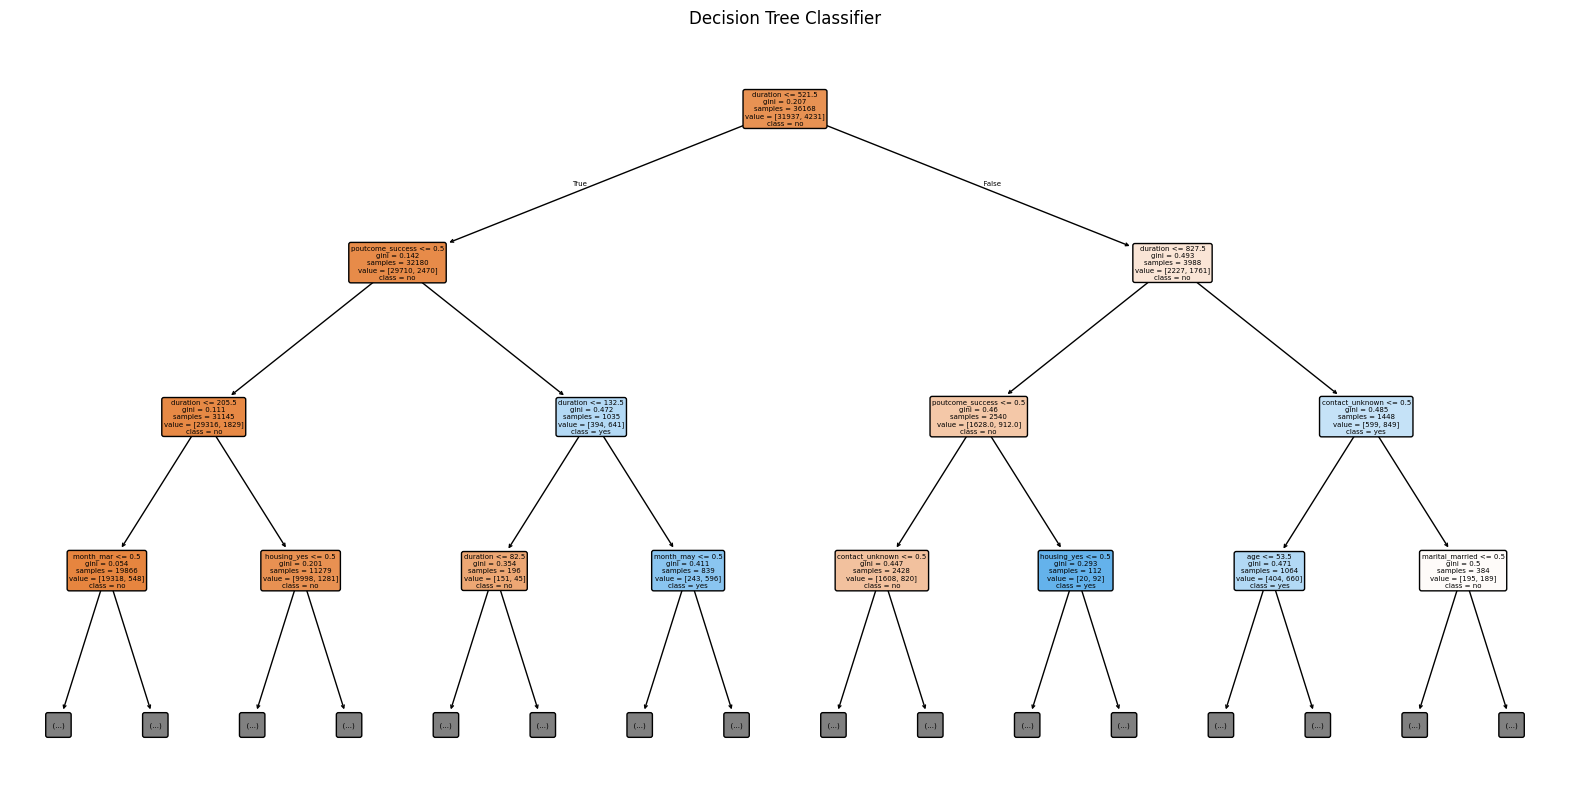

In [57]:
# --------------------------------------------
# 21. Visualize the Decision Tree
# --------------------------------------------

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X_encoded.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Classifier")
plt.show()

In [58]:
# --------------------------------------------
# 22. Feature Importance
# --------------------------------------------

feature_importance = pd.Series(
    model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))


Top 10 Important Features:
duration            0.551016
poutcome_success    0.297207
housing_yes         0.049952
age                 0.026724
pdays               0.017373
month_mar           0.016705
contact_unknown     0.015592
month_oct           0.010170
month_may           0.005023
marital_married     0.002160
dtype: float64


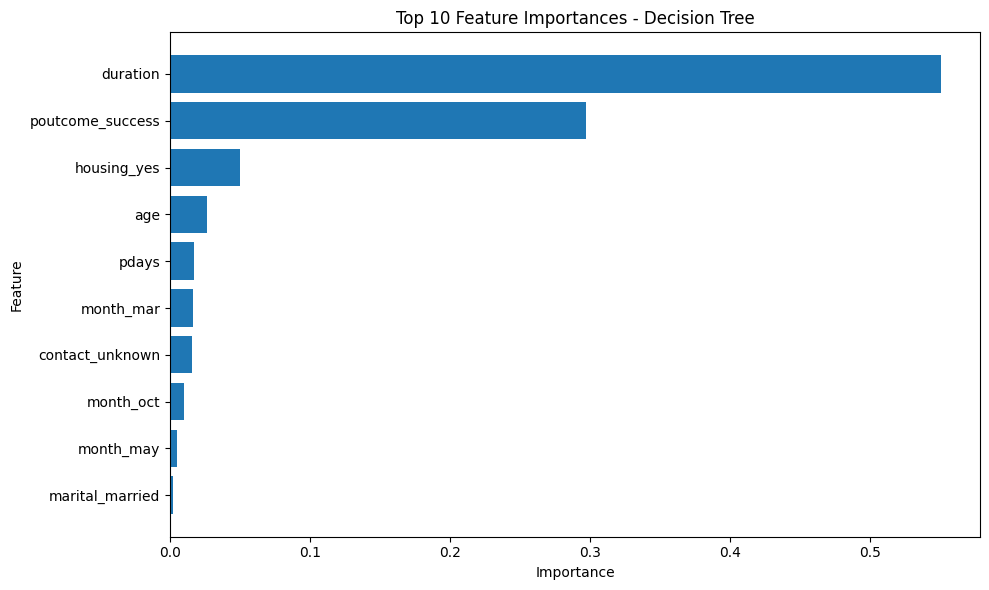

In [59]:
# --------------------------------------------
# 23. Feature Importance Bar Chart
# --------------------------------------------

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_features.index[::-1], top_features.values[::-1])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Decision Tree")

plt.tight_layout()
plt.show()

# Key Findings

1. The Decision Tree Classifier achieved an accuracy of 89.84% on
   the test dataset.

2. The model performed very well in identifying customers who did
   not subscribe to a term deposit, with a recall of 98% for the
   "no" class.

3. The recall for the "yes" class was 30%, indicating that the model
   missed some customers who actually subscribed to a term deposit.

4. The confusion matrix shows that 7,806 "no" cases and 318 "yes"
   cases were correctly classified.

5. Feature importance analysis shows that call duration was the most
   important feature, followed by previous campaign success and
   housing status.

6. The results show that the Decision Tree can effectively classify
   customer responses, although the lower recall for the "yes" class
   suggests that further model improvement could be explored.

# Conclusion

A Decision Tree Classifier was successfully developed using the Bank
Marketing dataset to predict whether a customer would subscribe to a
term deposit.

The model achieved an accuracy of 89.84% on the test dataset. The
analysis showed that the model was particularly effective at
identifying customers who did not subscribe.

Feature importance analysis indicated that call duration was the most
important feature, followed by previous campaign outcome and housing
status.

Although the model achieved good overall accuracy, its lower recall
for the "yes" class indicates that there is room for improvement in
identifying potential customers who are likely to subscribe.